In [1]:
import sys
sys.path.append('../src')
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from astropy.stats import sigma_clipped_stats

import hsc_downloader
from hsc_downloader import download_hsc_cutout

field_centers = [(150.106, 2.22092), (150.406, 2.52092)]

large_backgrounds = []
for ra, dec in field_centers:
    hdul_f = download_hsc_cutout(ra_center=ra, dec_center=dec, size_arcsec=400)
    large_backgrounds.append(hdul_f[1].data)

field_noise_stats = []
for field_bg in large_backgrounds:
    mean, median, std = sigma_clipped_stats(field_bg, sigma=3.0)
    field_noise_stats.append({'median': median, 'std': std})

print(field_noise_stats)

[{'median': np.float32(0.005664267), 'std': np.float32(0.013459231)}, {'median': np.float32(0.0063721426), 'std': np.float32(0.015171253)}]


In [2]:
metadata_with_heads = pd.read_parquet('../data/processed/injected_v1/injected_dataset_metadata_with_heads.parquet')

import head_labels
import importlib
importlib.reload(head_labels)
from lenstronomy.SimulationAPI.sim_api import SimAPI

def compute_snr_for_row(row, field_noise_stats, numPix=120, pixel_scale=0.168):
    if row['label'] == 0:
        return np.nan

    kwargs_lens = [{'theta_E': row['theta_E'], 'e1': row['e1_lens'], 'e2': row['e2_lens'],
                     'center_x': 0.0, 'center_y': 0.0}]
    kwargs_lens_light = [{'amp': row['amp_lens_light'], 'R_sersic': row['R_sersic_lens_light'],
                           'n_sersic': 4, 'e1': row['e1_lens'], 'e2': row['e2_lens'],
                           'center_x': 0.0, 'center_y': 0.0}]
    kwargs_source = [{'amp': 100, 'R_sersic': row['R_sersic_source'], 'n_sersic': row['n_sersic_source'],
                       'e1': row['e1_source'], 'e2': row['e2_source'],
                       'center_x': row['source_x'], 'center_y': row['source_y']}]

    kwargs_data = {
        'pixel_scale': pixel_scale, 'exposure_time': 100, 'magnitude_zero_point': 25.0,
        'sky_brightness': 30.0, 'read_noise': 0.001, 'ccd_gain': 2.5, 'psf_type': 'NONE'
    }
    sim_api = SimAPI(numpix=numPix, kwargs_single_band=kwargs_data, kwargs_model={
        'lens_model_list': ['SIE'], 'source_light_model_list': ['SERSIC_ELLIPSE'],
        'lens_light_model_list': ['SERSIC_ELLIPSE']
    })
    image_model = sim_api.image_model_class()

    full_signal = image_model.image(kwargs_lens=kwargs_lens, kwargs_source=kwargs_source, kwargs_lens_light=kwargs_lens_light)
    galaxy_only = image_model.image(kwargs_lens=kwargs_lens, kwargs_source=[{**kwargs_source[0], 'amp': 0}], kwargs_lens_light=kwargs_lens_light)
    isolated_arc = full_signal - galaxy_only

    total_signal_flux = np.sum(isolated_arc)
    n_significant_pixels = np.sum(isolated_arc > 0.01 * isolated_arc.max())

    field_std = field_noise_stats[int(row['field_idx'])]['std']
    snr = total_signal_flux / (field_std * np.sqrt(max(n_significant_pixels, 1)))

    return snr


from tqdm import tqdm

snr_values = []
for _, row in tqdm(metadata_with_heads.iterrows(), total=len(metadata_with_heads), desc="Computing SNR"):
    snr_values.append(compute_snr_for_row(row, field_noise_stats))

metadata_with_heads['snr'] = snr_values
print(metadata_with_heads[metadata_with_heads['label']==1]['snr'].describe())

Computing SNR: 100%|██████████| 3988/3988 [00:09<00:00, 434.72it/s] 

count     1993.000000
mean      2904.501269
std       2062.686073
min        358.338532
25%       1479.921563
50%       2404.204035
75%       3729.715394
max      18757.711922
Name: snr, dtype: float64


In [3]:
with h5py.File('../data/processed/injected_v1/injected_dataset.h5', 'r') as f:
    images = f['images'][:]

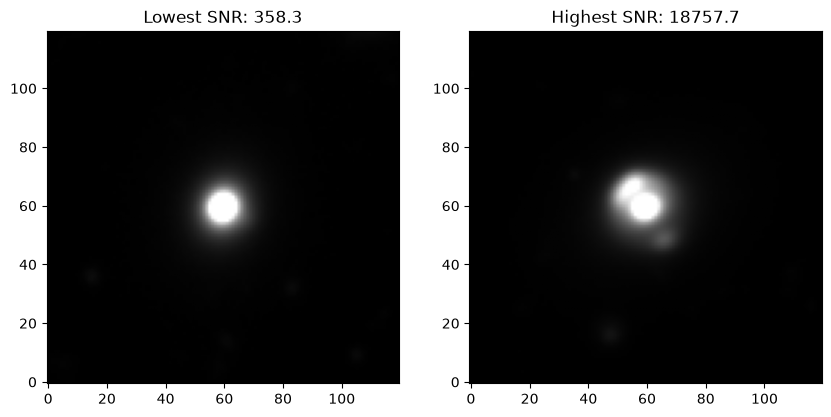

In [4]:
lens_only_meta = metadata_with_heads[metadata_with_heads['label'] == 1].reset_index(drop=True)
lens_only_images = images[metadata_with_heads['label'] == 1]

lowest_snr_idx = lens_only_meta['snr'].idxmin()
highest_snr_idx = lens_only_meta['snr'].idxmax()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(lens_only_images[lowest_snr_idx], cmap='gray', origin='lower')
axes[0].set_title(f"Lowest SNR: {lens_only_meta['snr'].iloc[lowest_snr_idx]:.1f}")
axes[1].imshow(lens_only_images[highest_snr_idx], cmap='gray', origin='lower')
axes[1].set_title(f"Highest SNR: {lens_only_meta['snr'].iloc[highest_snr_idx]:.1f}")
plt.show()

In [5]:
lens_indices_sorted = metadata_with_heads[metadata_with_heads['label']==1].sort_values('snr', ascending=False).index.values
nonlens_indices = metadata_with_heads[metadata_with_heads['label']==0].index.values

n_stages = 4
stage_boundaries = np.linspace(0, len(lens_indices_sorted), n_stages + 1).astype(int)

print("Stage sizes (cumulative lens examples introduced):", stage_boundaries)

for i in range(n_stages):
    stage_snr_range = metadata_with_heads.loc[lens_indices_sorted[stage_boundaries[i]:stage_boundaries[i+1]], 'snr']
    print(f"Stage {i+1}: SNR range {stage_snr_range.min():.0f} - {stage_snr_range.max():.0f}, n={len(stage_snr_range)}")

Stage sizes (cumulative lens examples introduced): [   0  498  996 1494 1993]
Stage 1: SNR range 3734 - 18758, n=498
Stage 2: SNR range 2405 - 3730, n=498
Stage 3: SNR range 1480 - 2404, n=498
Stage 4: SNR range 358 - 1480, n=499


In [6]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn

labels_all = metadata_with_heads['label'].values
indices = np.arange(len(images))
train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=labels_all, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=labels_all[temp_idx], random_state=42)

train_metadata = metadata_with_heads.iloc[train_idx].reset_index(drop=True)
train_images = images[train_idx]

print(len(train_idx), len(val_idx), len(test_idx))

train_lens_sorted = train_metadata[train_metadata['label']==1].sort_values('snr', ascending=False).index.values
train_nonlens_all = train_metadata[train_metadata['label']==0].index.values

stage_boundaries_train = np.linspace(0, len(train_lens_sorted), n_stages + 1).astype(int)
print("Train stage sizes:", stage_boundaries_train)

2791 598 599
Train stage sizes: [   0  348  697 1046 1395]


In [7]:
class CurriculumLensDataset(Dataset):
    def __init__(self, images, metadata_df):
        self.images = images
        self.labels = metadata_df['label'].values

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = torch.from_numpy(self.images[idx]).float().unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label


def build_stage_loader(stage_num, train_lens_sorted, train_nonlens_all, stage_boundaries_train,
                          train_images, train_metadata, batch_size=32):
    lens_subset_idx = train_lens_sorted[:stage_boundaries_train[stage_num]]

    n_nonlens_needed = len(lens_subset_idx)
    nonlens_subset_idx = np.random.choice(train_nonlens_all, size=min(n_nonlens_needed, len(train_nonlens_all)), replace=False)

    combined_idx = np.concatenate([lens_subset_idx, nonlens_subset_idx])
    np.random.shuffle(combined_idx)

    stage_dataset = CurriculumLensDataset(train_images[combined_idx], train_metadata.iloc[combined_idx])
    return DataLoader(stage_dataset, batch_size=batch_size, shuffle=True), len(combined_idx)

In [8]:
np.random.seed(42)
stage1_loader, stage1_size = build_stage_loader(1, train_lens_sorted, train_nonlens_all, stage_boundaries_train, train_images, train_metadata)
print("Stage 1 size:", stage1_size)

sample_batch = next(iter(stage1_loader))
print(sample_batch[0].shape, sample_batch[1].shape)
print("Label balance in batch:", sample_batch[1].float().mean().item())

Stage 1 size: 696
torch.Size([32, 1, 120, 120]) torch.Size([32])
Label balance in batch: 0.59375


In [10]:
import timm
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

encoder = timm.create_model('hf_hub:mwalmsley/zoobot-encoder-greyscale-convnext_nano', pretrained=True, in_chans=1, num_classes=0)

class LensClassifier(nn.Module):
    def __init__(self, encoder, feature_dim=640, num_classes=2):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        return self.classifier(self.encoder(x))

curriculum_model = LensClassifier(encoder).to(device)
optimizer = optim.Adam(curriculum_model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

val_dataset = CurriculumLensDataset(images[val_idx], metadata_with_heads.iloc[val_idx])
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

def train_one_epoch_simple(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for images_batch, labels_batch in loader:
        images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)
        optimizer.zero_grad()
        outputs = model(images_batch)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * images_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels_batch).sum().item()
        total += labels_batch.size(0)
    return total_loss / total, correct / total

def evaluate_simple(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images_batch, labels_batch in loader:
            images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)
            outputs = model(images_batch)
            loss = criterion(outputs, labels_batch)
            total_loss += loss.item() * images_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels_batch).sum().item()
            total += labels_batch.size(0)
    return total_loss / total, correct / total


epochs_per_stage = 4
best_val_loss = float('inf')
curriculum_history = []

for stage_num in range(1, n_stages + 1):
    stage_loader, stage_size = build_stage_loader(stage_num, train_lens_sorted, train_nonlens_all,
                                                     stage_boundaries_train, train_images, train_metadata)
    print(f"\n=== Stage {stage_num}/{n_stages} (size={stage_size}) ===")

    for epoch in range(epochs_per_stage):
        train_loss, train_acc = train_one_epoch_simple(curriculum_model, stage_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate_simple(curriculum_model, val_loader, criterion, device)

        marker = ""
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(curriculum_model.state_dict(), '../models/curriculum_convnext_nano_best.pt')
            marker = " [NEW BEST]"

        print(f"  Stage {stage_num}, Epoch {epoch+1}/{epochs_per_stage} - train_loss: {train_loss:.4f}, "
              f"train_acc: {train_acc:.4f}, val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}{marker}")

        curriculum_history.append({'stage': stage_num, 'epoch': epoch+1, 'train_loss': train_loss,
                                     'train_acc': train_acc, 'val_loss': val_loss, 'val_acc': val_acc})


=== Stage 1/4 (size=696) ===
  Stage 1, Epoch 1/4 - train_loss: 0.5265, train_acc: 0.7586, val_loss: 0.4535, val_acc: 0.7759 [NEW BEST]
  Stage 1, Epoch 2/4 - train_loss: 0.1668, train_acc: 0.9454, val_loss: 0.3593, val_acc: 0.8712 [NEW BEST]
  Stage 1, Epoch 3/4 - train_loss: 0.0710, train_acc: 0.9698, val_loss: 0.5749, val_acc: 0.8662
  Stage 1, Epoch 4/4 - train_loss: 0.0299, train_acc: 0.9899, val_loss: 0.3232, val_acc: 0.9298 [NEW BEST]

=== Stage 2/4 (size=1394) ===
  Stage 2, Epoch 1/4 - train_loss: 0.0505, train_acc: 0.9835, val_loss: 0.5565, val_acc: 0.9214
  Stage 2, Epoch 2/4 - train_loss: 0.0222, train_acc: 0.9950, val_loss: 0.3035, val_acc: 0.9532 [NEW BEST]
  Stage 2, Epoch 3/4 - train_loss: 0.0133, train_acc: 0.9971, val_loss: 0.2545, val_acc: 0.9565 [NEW BEST]
  Stage 2, Epoch 4/4 - train_loss: 0.0120, train_acc: 0.9978, val_loss: 0.3478, val_acc: 0.9582

=== Stage 3/4 (size=2092) ===
  Stage 3, Epoch 1/4 - train_loss: 0.0968, train_acc: 0.9761, val_loss: 0.3499, val_a

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

eval_curriculum_model = LensClassifier(timm.create_model('hf_hub:mwalmsley/zoobot-encoder-greyscale-convnext_nano', pretrained=False, in_chans=1, num_classes=0)).to(device)
eval_curriculum_model.load_state_dict(torch.load('../models/curriculum_convnext_nano_best.pt'))
eval_curriculum_model.eval()

test_dataset = CurriculumLensDataset(images[test_idx], metadata_with_heads.iloc[test_idx])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

all_preds_c = []
all_labels_c = []
with torch.no_grad():
    for images_batch, labels_batch in test_loader:
        images_batch = images_batch.to(device)
        outputs = eval_curriculum_model(images_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds_c.extend(predicted.cpu().numpy())
        all_labels_c.extend(labels_batch.numpy())

print(classification_report(all_labels_c, all_preds_c, target_names=['non-lens', 'lens']))
print(confusion_matrix(all_labels_c, all_preds_c))

              precision    recall  f1-score   support

    non-lens       0.98      1.00      0.99       300
        lens       1.00      0.98      0.99       299

    accuracy                           0.99       599
   macro avg       0.99      0.99      0.99       599
weighted avg       0.99      0.99      0.99       599

[[299   1]
 [  7 292]]
